In [128]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import geopandas as gpd




In [129]:
df = pd.read_csv("saveecobot_city_districts_pm25_and_aqi_pm25.csv")
loc = pd.read_csv("saveecobot_city_districts.csv")
# https://data.gov.ua/dataset/51558857-4f00-4166-bd0b-152e8e637434

print(df.columns.tolist())
print(loc.columns.tolist())



 
df.info()
df.describe()


C:\Users\irish\AppData\Local\Temp\ipykernel_9912\2911627554.py:1: DtypeWarning: Columns (0,1,2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("saveecobot_city_districts_pm25_and_aqi_pm25.csv")


['district_id', 'aqi', 'pm25', 'logged_at']
['id', 'region_name', 'city_type_name', 'city_name', 'district_name', 'city_id', 'koatuu']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2673804 entries, 0 to 2673803
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   district_id  object
 1   aqi          object
 2   pm25         object
 3   logged_at    object
dtypes: object(4)
memory usage: 81.6+ MB


,district_id,aqi,pm25,logged_at
count,2673804,2673804,2652735.0,2673804
unique,122,641,210409.0,59959
top,6,15,0.0,2021-10-12 13:00:00
freq,56475,50512,4684.0,67


In [130]:
df.head()

,district_id,aqi,pm25,logged_at
0,4,67,17.73,2019-02-27 23:00:00
1,4,66,17.23,2019-02-28 00:00:00
2,4,64,15.88,2019-02-28 01:00:00
3,4,63,35.26,2019-02-28 02:00:00
4,4,80,75.74,2019-02-28 03:00:00


In [ ]:
df['district_id'] = pd.to_numeric(df['district_id'], errors='coerce')
df['aqi'] = pd.to_numeric(df['aqi'], errors='coerce')
df['pm25'] = pd.to_numeric(df['pm25'], errors='coerce')
pd.to_datetime(df.logged_at.head(), utc=True, format='%Y-%m-%d %H:%M:%S')

0   2019-02-27 23:00:00+00:00
1   2019-02-28 00:00:00+00:00
2   2019-02-28 01:00:00+00:00
3   2019-02-28 02:00:00+00:00
4   2019-02-28 03:00:00+00:00
Name: logged_at, dtype: datetime64[ns, UTC]

In [132]:
df.isnull().sum()

district_id        1
aqi                1
pm25           21070
logged_at          0
dtype: int64

In [133]:
(df.isna().mean() * 100).round(2)

district_id    0.00
aqi            0.00
pm25           0.79
logged_at      0.00
dtype: float64

In [134]:
df[df.isna().any(axis=1)]

,district_id,aqi,pm25,logged_at
141,4.0,52.0,NaN,2019-03-05 20:00:00
142,4.0,52.0,NaN,2019-03-05 21:00:00
768,4.0,49.0,NaN,2019-04-01 23:00:00
769,4.0,49.0,NaN,2019-04-02 00:00:00
1056,4.0,80.0,NaN,2019-04-14 20:00:00
...,...,...,...,...
2671229,15.0,12.0,NaN,2025-12-28 17:00:00
2671232,21.0,9.0,NaN,2025-12-28 17:00:00
2671917,15.0,11.0,NaN,2025-12-29 14:00:00
2672364,20.0,24.0,NaN,2025-12-30 04:00:00


In [135]:
df.duplicated().sum()

np.int64(31)

In [136]:
df[df.duplicated()]

,district_id,aqi,pm25,logged_at
1558646,83.0,60.0,15.6200,2022-04-22 14:00:00
1558648,83.0,59.0,13.9600,2022-04-22 15:00:00
1567109,84.0,20.0,2.6500,2022-04-22 14:00:00
1567111,84.0,15.0,4.2200,2022-04-22 15:00:00
1583116,92.0,46.0,10.7767,2022-04-22 14:00:00
1583118,92.0,45.0,12.6917,2022-04-22 15:00:00
1591867,95.0,67.0,19.9900,2022-04-22 14:00:00
1591869,95.0,66.0,18.8360,2022-04-22 15:00:00
1600623,96.0,69.0,19.9529,2022-04-22 14:00:00
1600625,96.0,68.0,18.8107,2022-04-22 15:00:00


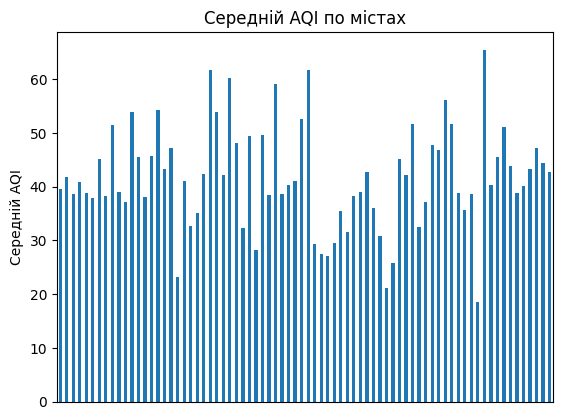

In [137]:
import matplotlib.pyplot as plt

# групування + сортування по district_id
mean_aqi = (
    df.groupby('district_id')['aqi']
      .mean()
      .sort_index()
)

plt.figure()

mean_aqi.plot(kind='bar')

plt.xlabel("") 
plt.ylabel("Середній AQI")
plt.title("Середній AQI по містах")

plt.xticks([])

plt.show()

In [138]:
loc.info()
loc.head()
loc.describe

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              79 non-null     int64 
 1   region_name     79 non-null     object
 2   city_type_name  79 non-null     object
 3   city_name       79 non-null     object
 4   district_name   79 non-null     object
 5   city_id         79 non-null     int64 
 6   koatuu          79 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 4.4+ KB


<bound method NDFrame.describe of      id               region_name city_type_name city_name  \
0     4  Дніпропетровська область          місто    Дніпро   
1     5  Дніпропетровська область          місто    Дніпро   
2     6  Дніпропетровська область          місто    Дніпро   
3     7  Дніпропетровська область          місто    Дніпро   
4     8  Дніпропетровська область          місто    Дніпро   
..  ...                       ...            ...       ...   
74  100                      Київ          місто      Київ   
75  101                      Київ          місто      Київ   
76  102                      Київ          місто      Київ   
77  103                      Київ          місто      Київ   
78  104                      Київ          місто      Київ   

                    district_name  city_id      koatuu  
0   Амур-Нижньодніпровський район        1  1210136300  
1            Шевченківський район        1  1210136600  
2                  Соборний район        1  121013

In [139]:
loc['id'] = pd.to_numeric(loc['id'], errors='coerce')

df = df.merge(
    loc[['id', 'region_name']],
    left_on='district_id',
    right_on='id',
    how='left'
)


print("Порожніх oblast після merge:", df['region_name'].isna().sum())

Порожніх oblast після merge: 1


In [140]:


ua_map = gpd.read_file("regiony.geojson")

print(ua_map.columns)
print(ua_map.head())


Index(['fid', 'region', 'geometry'], dtype='object')
   fid                     region  \
0    0  Автономна Республіка Крим   
1    1          Вінницька область   
2    2          Волинська область   
3    3   Дніпропетровська область   
4    4           Донецька область   

                                            geometry  
0  MULTIPOLYGON (((33.6463 46.2295, 33.7018 46.19...  
1  MULTIPOLYGON (((28.8799 49.8893, 28.9016 49.86...  
2  MULTIPOLYGON (((25.2261 51.9601, 25.2616 51.96...  
3  MULTIPOLYGON (((34.9487 49.1928, 35.0126 49.14...  
4  MULTIPOLYGON (((37.8905 49.2187, 37.9355 49.19...  


In [141]:


OBLAST_COL = 'region_name'  

oblast_aqi = (
    df.dropna(subset=[OBLAST_COL, 'aqi'])
      .groupby(OBLAST_COL, as_index=False)['aqi']
      .mean()
      .rename(columns={OBLAST_COL: 'oblast', 'aqi': 'aqi_mean'})
)

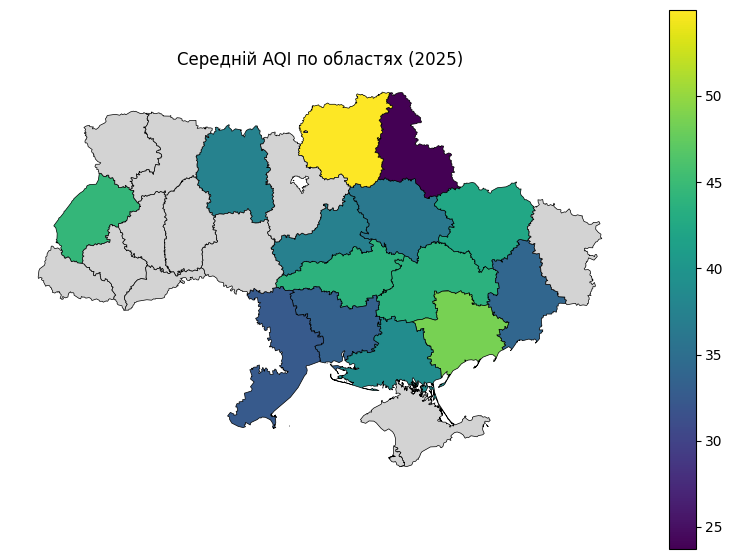

In [142]:
gdf = gpd.read_file("regiony.geojson")
GEO_NAME_COL = 'region'  

def norm(s):
    return (s.astype(str)
              .str.strip()
              .str.replace(r'\s+', ' ', regex=True)
              .str.lower())

gdf = gdf.rename(columns={GEO_NAME_COL: 'oblast_geo'})
gdf['oblast_key'] = norm(gdf['oblast_geo'])
oblast_aqi['oblast_key'] = norm(oblast_aqi['oblast'])

map_df = gdf.merge(oblast_aqi[['oblast_key', 'aqi_mean']], on='oblast_key', how='left')

fig, ax = plt.subplots(figsize=(10, 7))

map_df.plot(
    column='aqi_mean',
    legend=True,
    ax=ax,
    edgecolor='black',
    linewidth=0.5,
    missing_kwds={
        "color": "lightgrey",
        "label": "Немає даних"
    }
)

ax.set_title("Середній AQI по областях (2025)")
ax.set_axis_off()

plt.show()

In [143]:
df['logged_at'] = pd.to_datetime(df['logged_at'], errors='coerce')
df2 = df[[OBLAST_COL, 'logged_at', 'aqi', 'pm25']].copy()
df2 = df2.dropna(subset=[OBLAST_COL, 'logged_at'])

daily = (
    df2.set_index('logged_at')
       .groupby(OBLAST_COL)
       .resample('D')
       .agg({'aqi': 'mean', 'pm25': 'mean'})
       .reset_index()
)

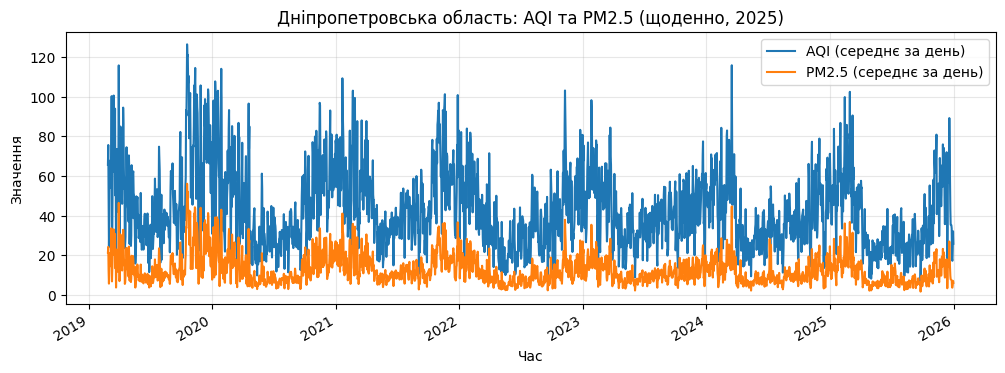

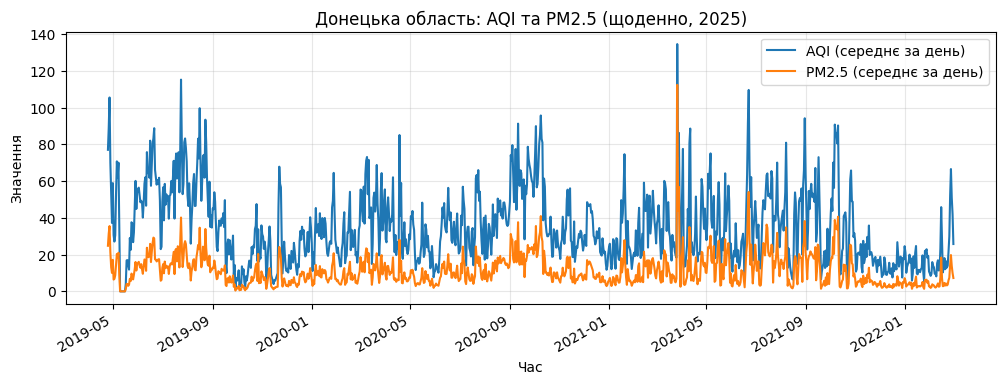

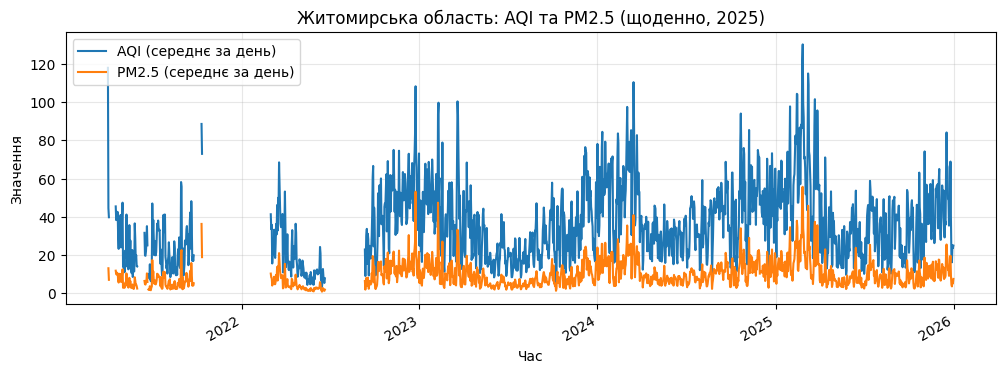

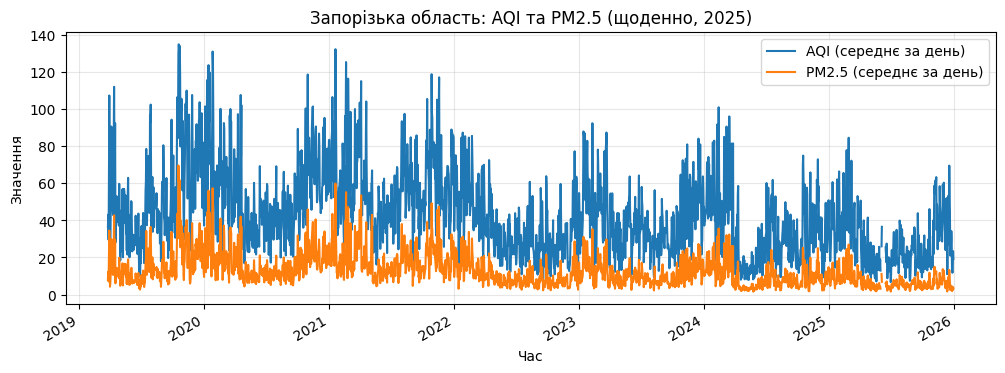

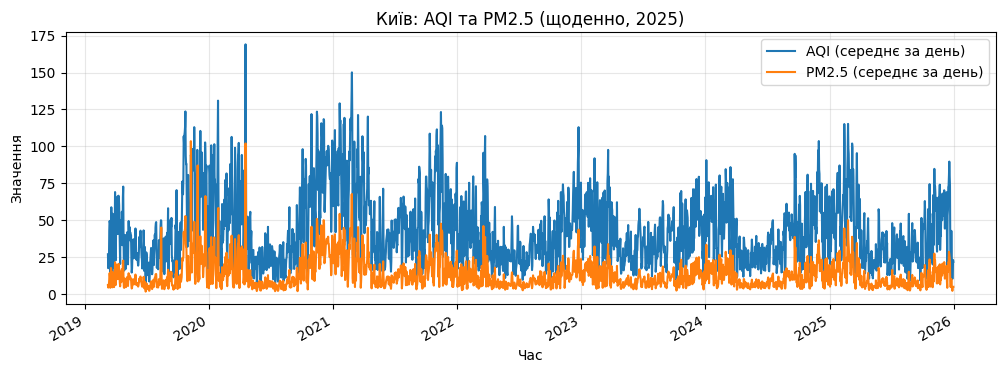

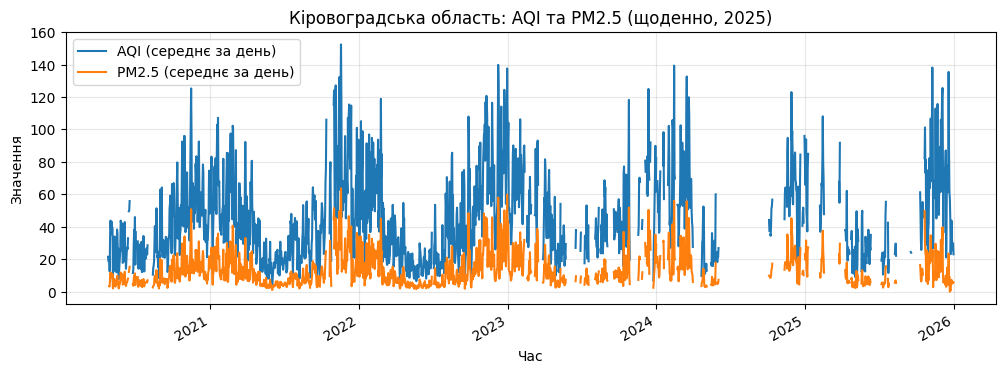

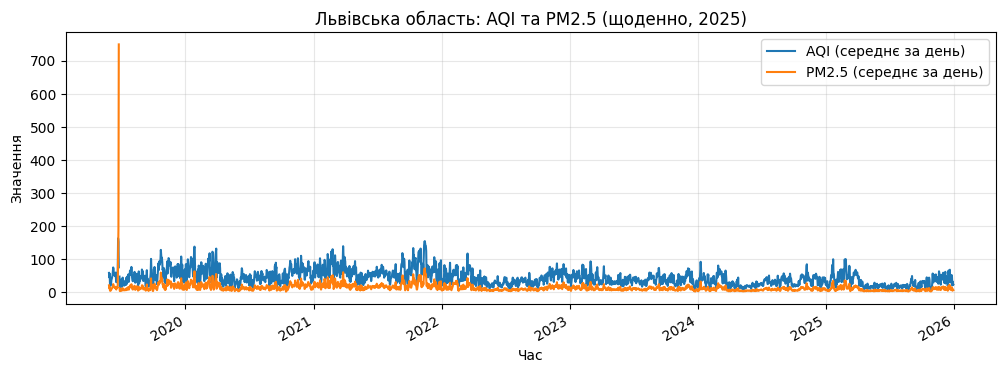

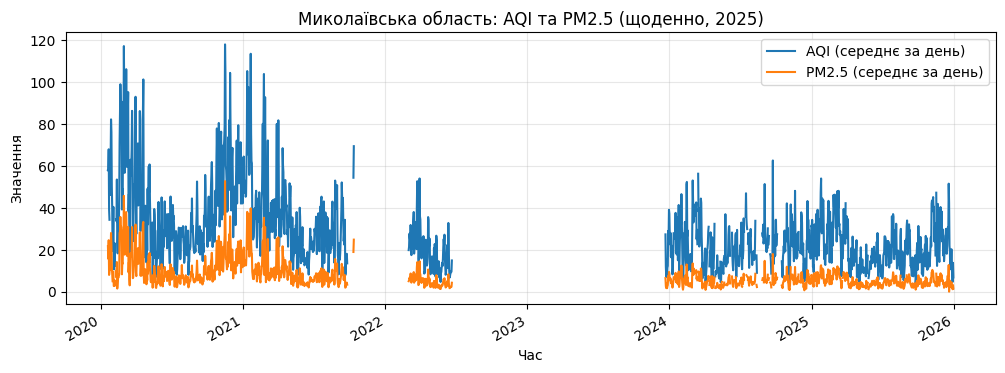

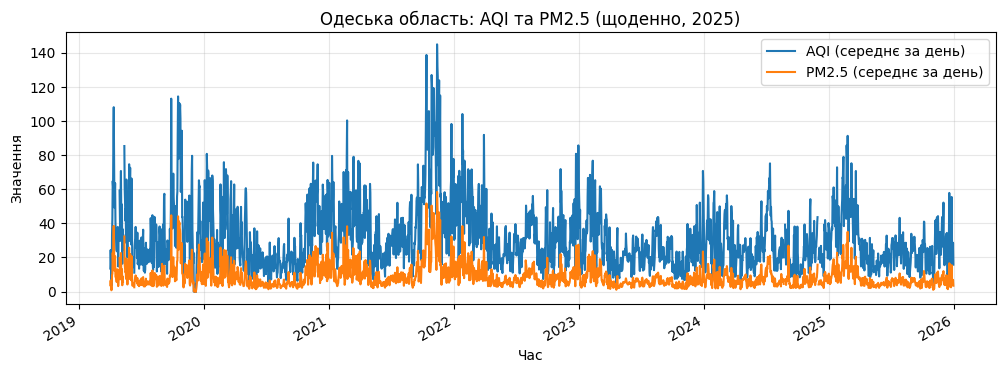

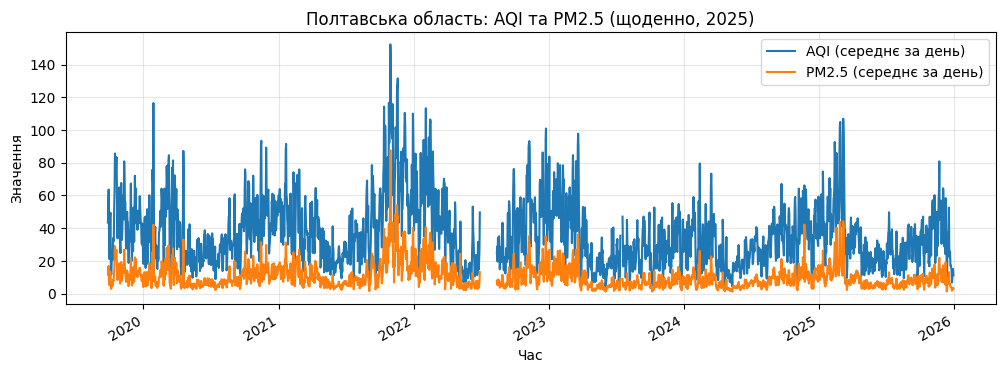

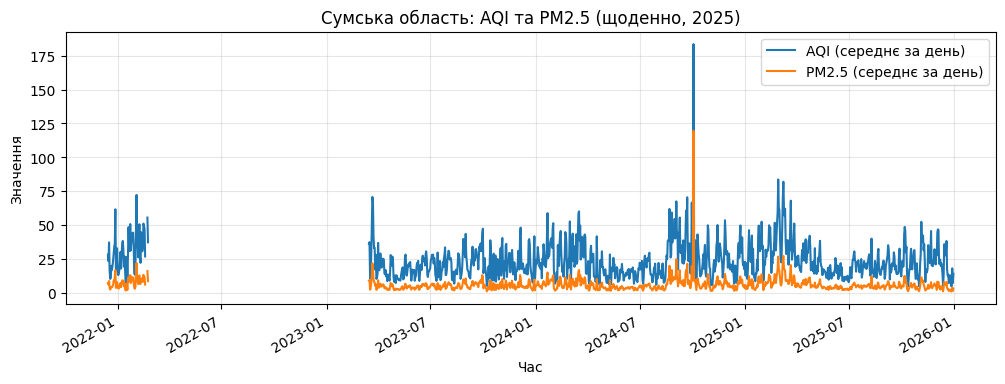

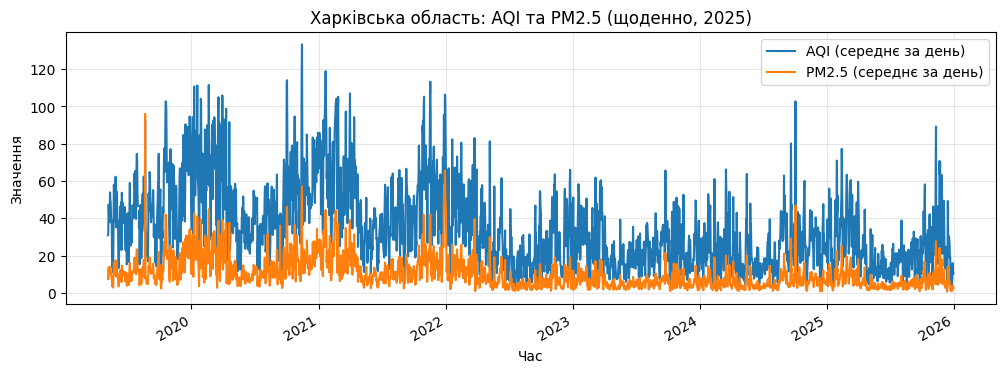

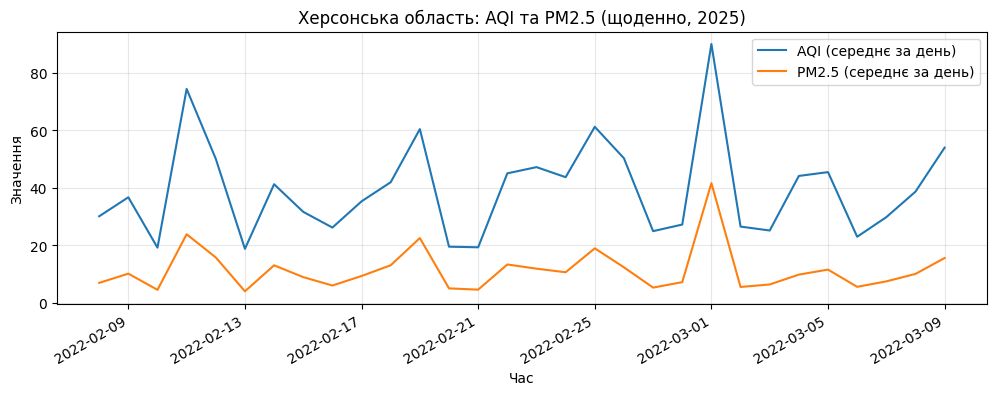

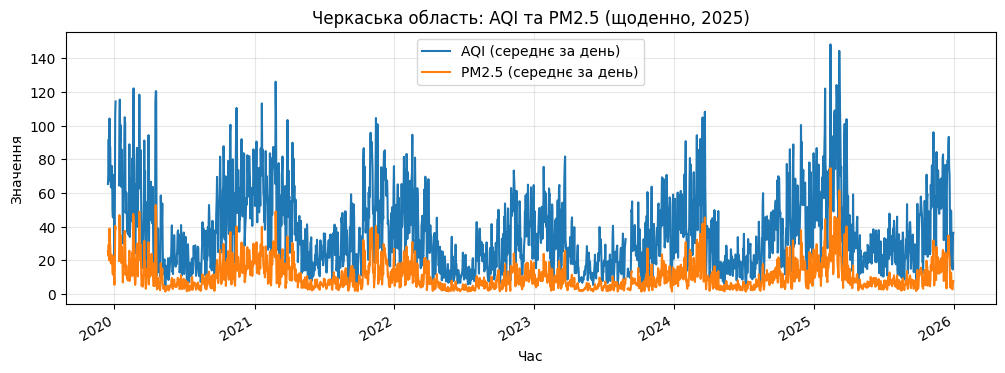

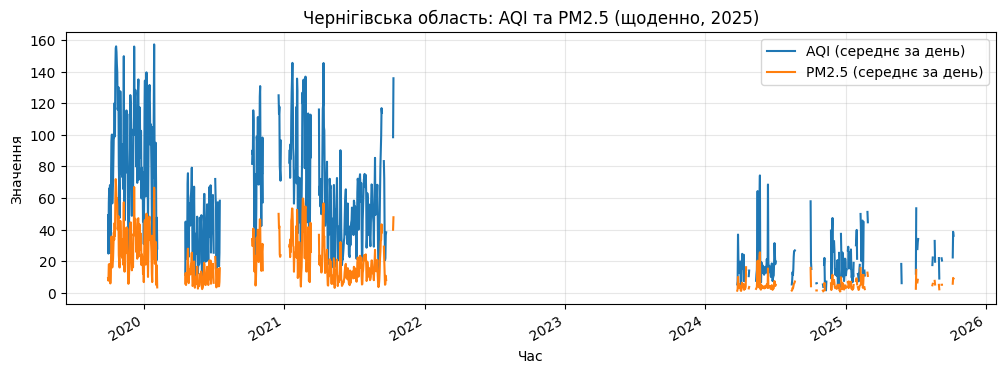

In [144]:
for oblast, g in daily.groupby(OBLAST_COL):
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(g['logged_at'], g['aqi'], label='AQI (середнє за день)')
    ax.plot(g['logged_at'], g['pm25'], label='PM2.5 (середнє за день)')

    ax.set_title(f"{oblast}: AQI та PM2.5 (щоденно, 2025)")
    ax.set_xlabel("Час")          # ✅ часова стрічка знизу
    ax.set_ylabel("Значення")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.autofmt_xdate()           # ✅ щоб дати не злипались
    plt.show()

OUTLIERS

In [145]:
def cap_outliers_by_group(group, column, min_size=10):
    if group[column].dropna().shape[0] < min_size:
        return group

    Q1 = group[column].quantile(0.25)
    Q3 = group[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    group = group.copy()
    group[column] = group[column].clip(lower=lower, upper=upper)
    return group

df_capped = df.copy()

for col in ['pm25', 'aqi']:
    df_capped = (
        df_capped
        .groupby('district_id', group_keys=False)
        .apply(lambda x: cap_outliers_by_group(x, col, min_size=10))
    )


C:\Users\irish\AppData\Local\Temp\ipykernel_9912\485925255.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: cap_outliers_by_group(x, col, min_size=10))
C:\Users\irish\AppData\Local\Temp\ipykernel_9912\485925255.py:22: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: cap_outliers_by_group(x, col, min_size=10))


In [151]:
df_without_outliers = df_capped[[OBLAST_COL, 'logged_at', 'aqi', 'pm25']].copy()
df_without_outliers = df_without_outliers.dropna(subset=[OBLAST_COL, 'logged_at'])

daily_without_outliers = (
    df_without_outliers.set_index('logged_at')
       .groupby(OBLAST_COL)
       .resample('D')
       .agg({'aqi': 'mean', 'pm25': 'mean'})
       .reset_index()
)

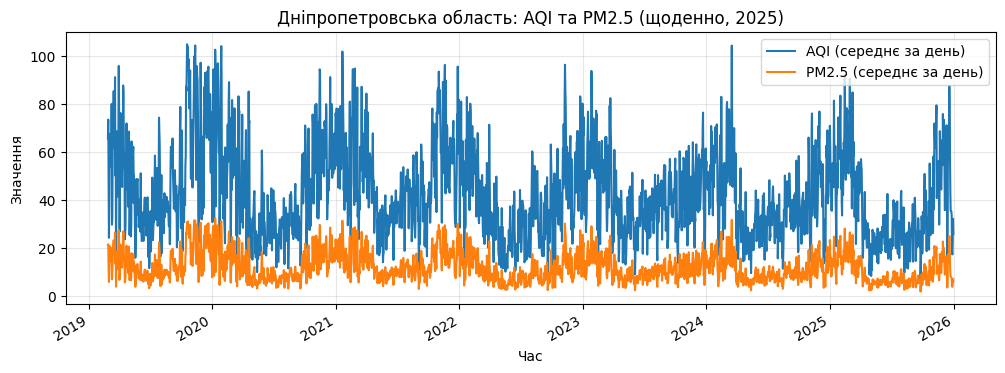

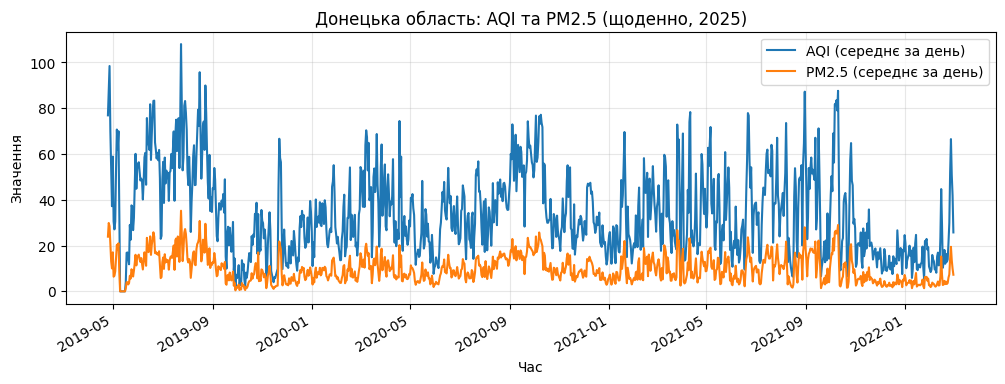

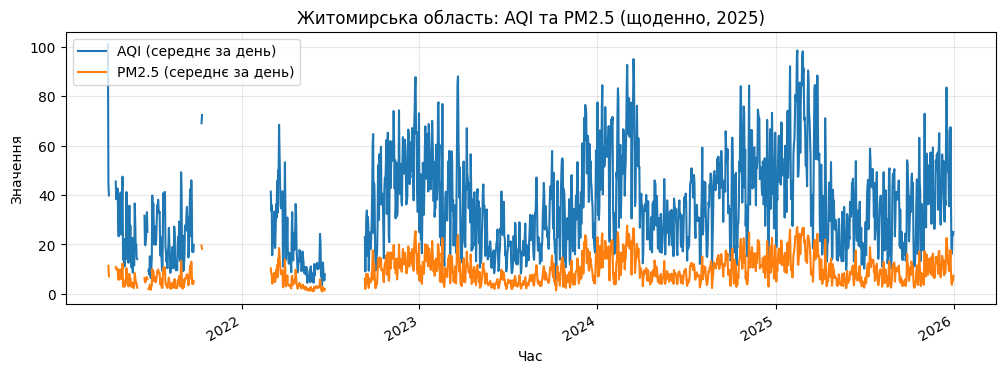

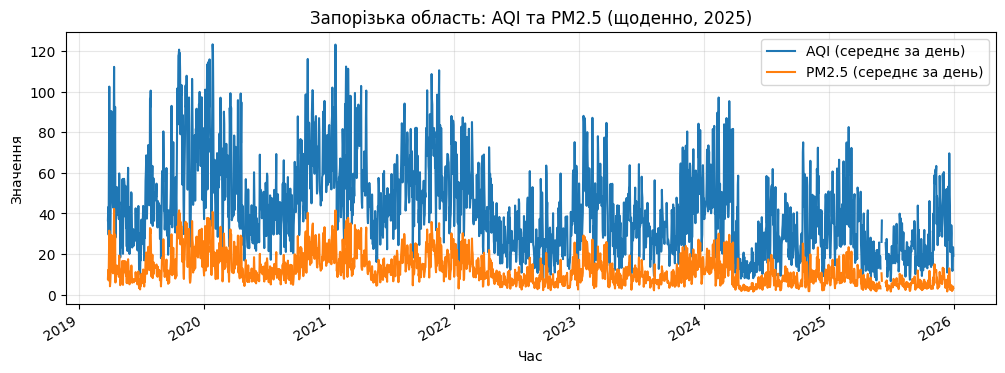

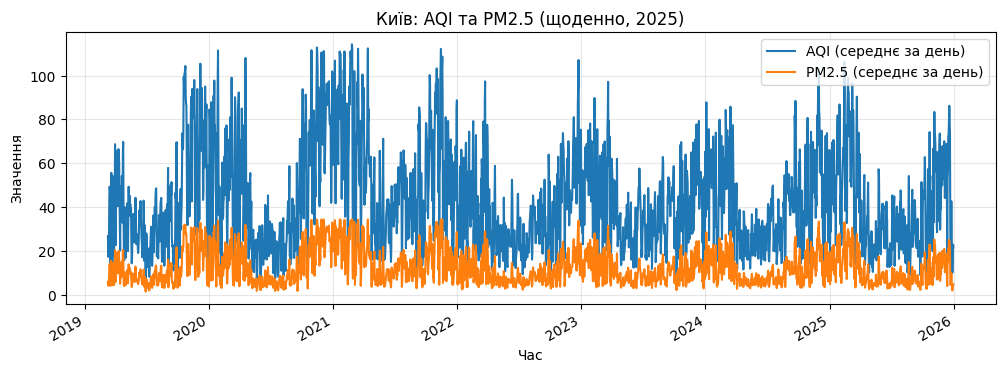

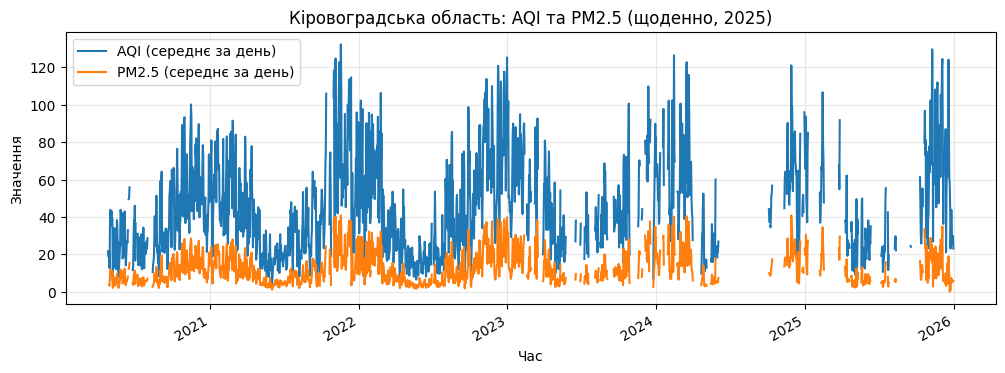

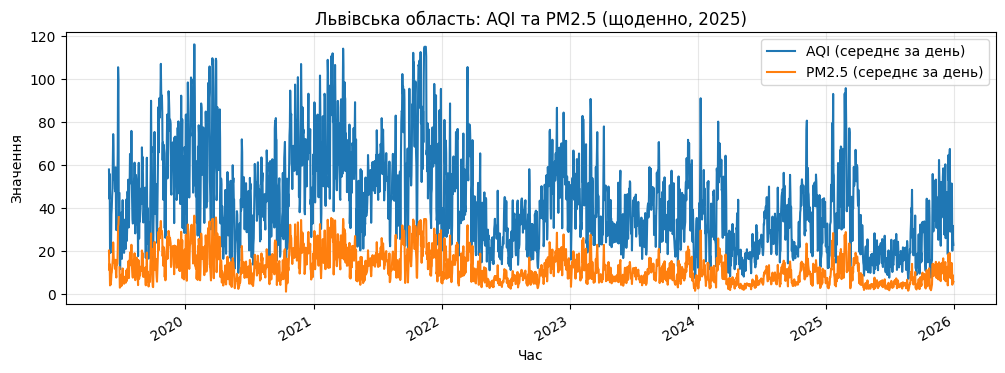

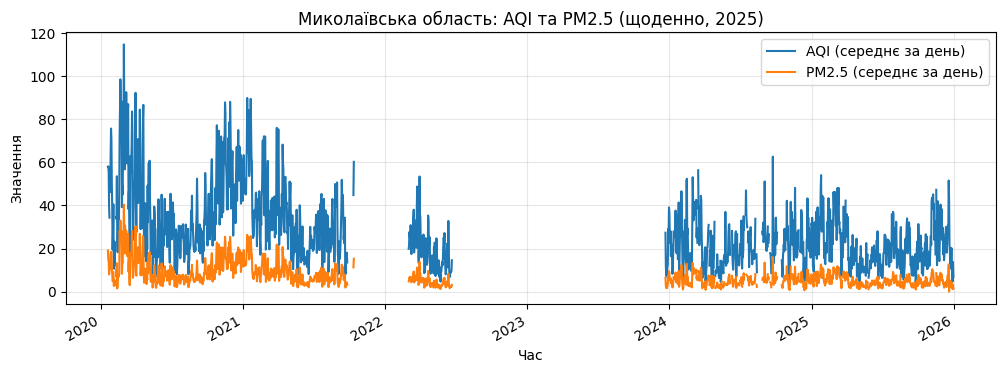

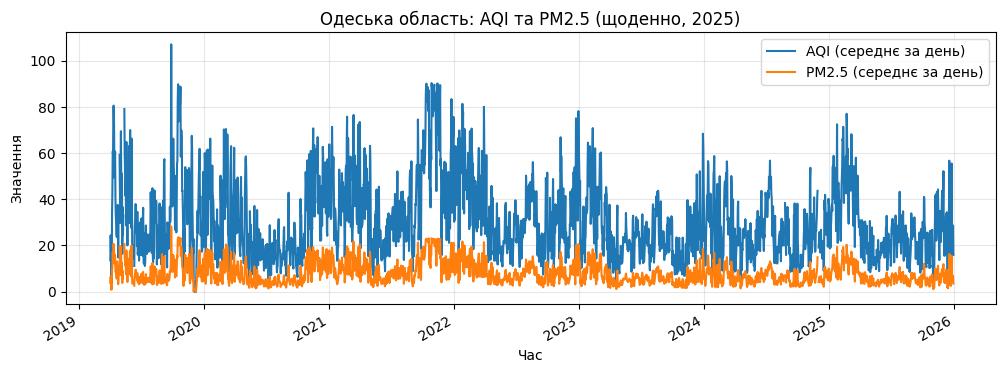

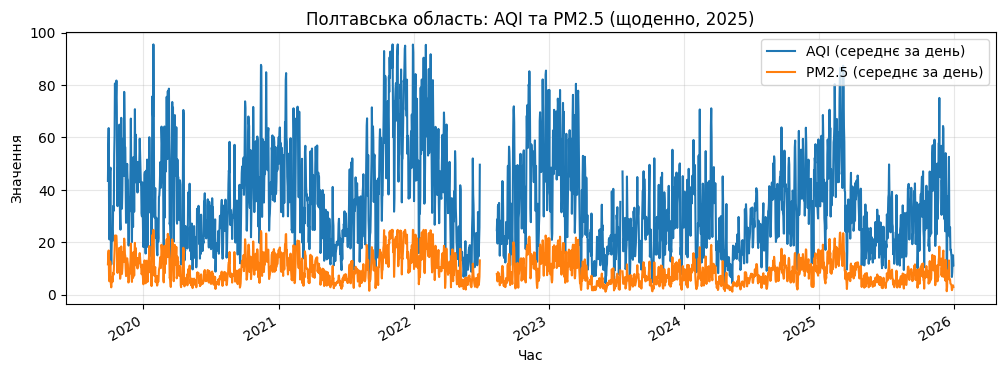

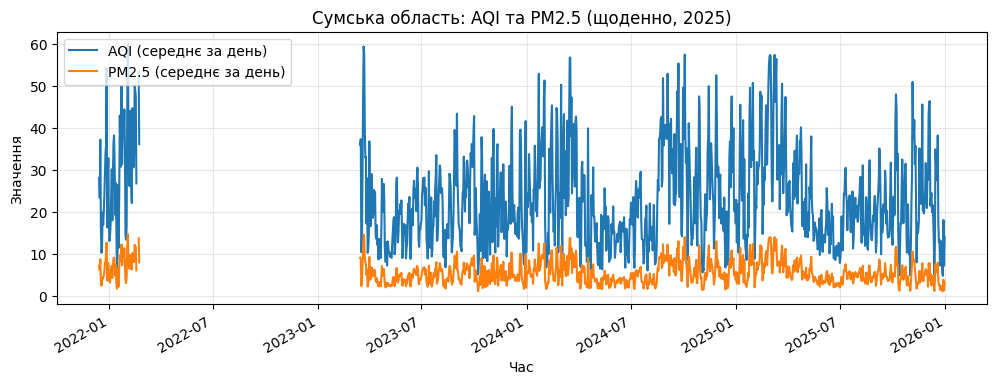

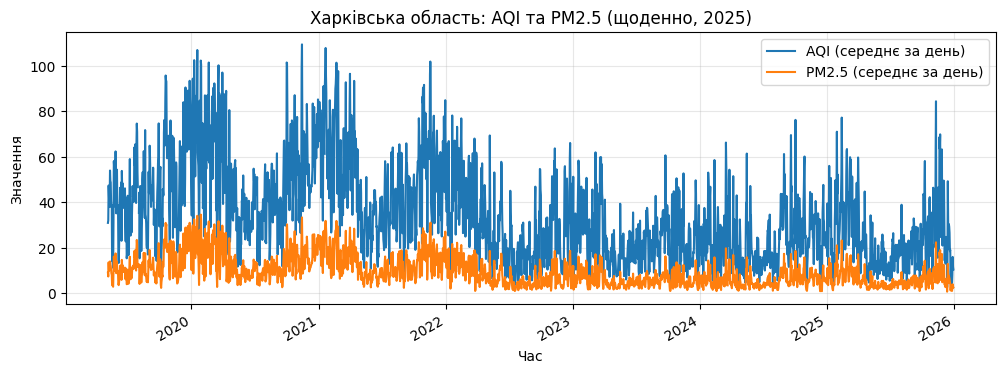

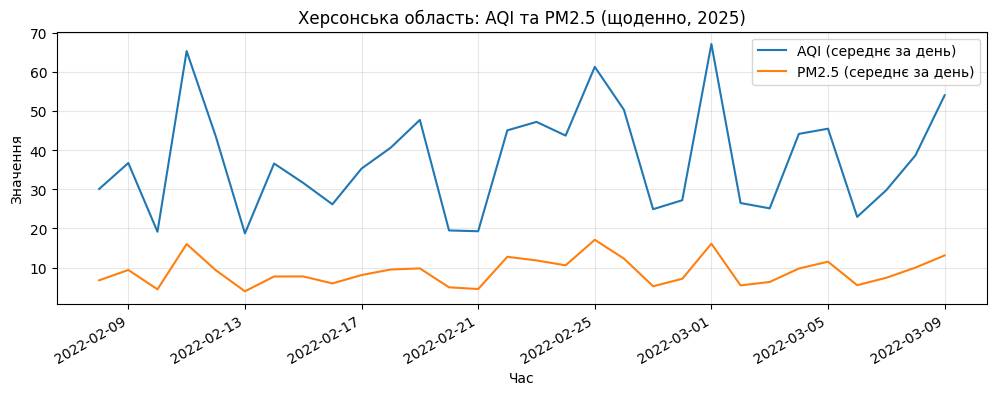

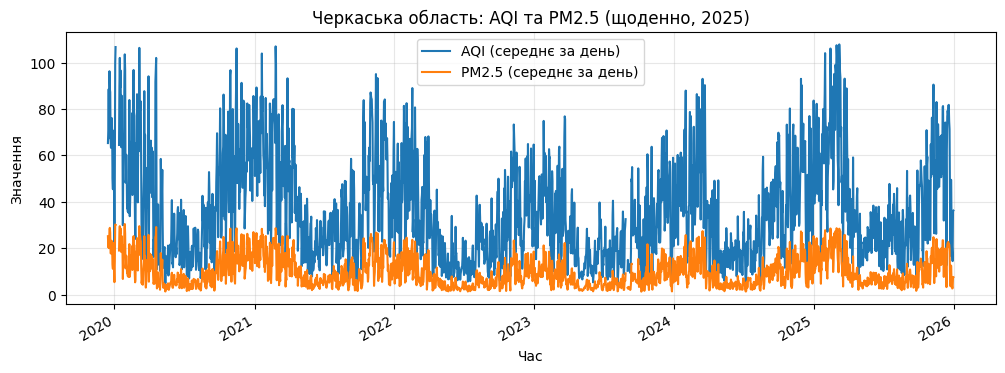

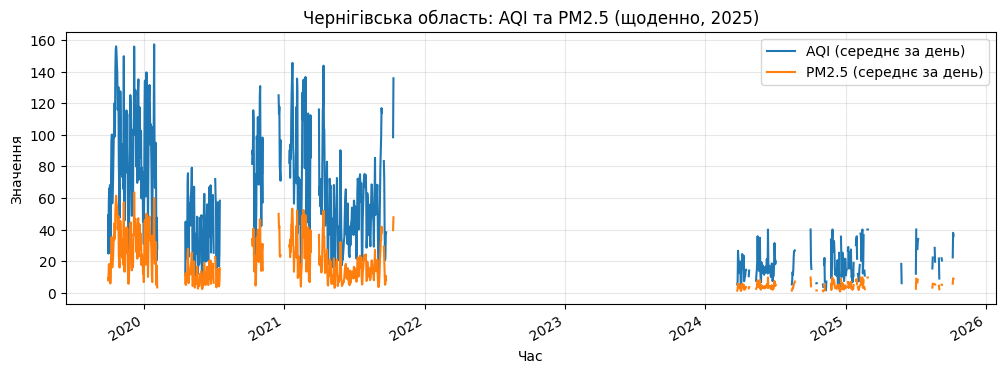

In [152]:
for oblast, g in daily_without_outliers.groupby(OBLAST_COL):
    fig, ax = plt.subplots(figsize=(12, 4))

    ax.plot(g['logged_at'], g['aqi'], label='AQI (середнє за день)')
    ax.plot(g['logged_at'], g['pm25'], label='PM2.5 (середнє за день)')

    ax.set_title(f"{oblast}: AQI та PM2.5 (щоденно, 2025)")
    ax.set_xlabel("Час")          # ✅ часова стрічка знизу
    ax.set_ylabel("Значення")
    ax.grid(True, alpha=0.3)
    ax.legend()

    fig.autofmt_xdate()           # ✅ щоб дати не злипались
    plt.show()